In [1]:
import os
os.environ["CELLPOSE_LOCAL_MODELS_PATH"] = "/Users/danyunhe/.cellpose/models"

In [5]:
#pip install cellpose

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
  Using cached cellpose-2.2-py3-none-any.whl (170 kB)
  Using cached fastremap-1.13.4-cp39-cp39-macosx_10_9_universal2.whl (1.2 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 6.4 MB/s eta 0:00:0000:0100:01
  Using cached tqdm-4.65.0-py3-none-any.whl (77 kB)
  Using cached numba-0.56.4-cp39-cp39-macosx_11_0_arm64.whl (2.4 MB)
  Using cached llvmlite-0.39.1-cp39-cp39-macosx_11_0_arm64.whl (23.1 MB)
  Using cached tifffile-2023.4.12-py3-none-any.whl (219 kB)
  Using cached torch-2.0.0-cp39-none-macosx_11_0_arm64.whl (55.8 MB)
  Using cached opencv_python_headless-4.7.0.72-cp37-abi3-macosx_11_0_arm64.whl (32.6 MB)
  Using cached natsort-8.3.1-py3-none-any.whl (38 kB)
  Using cached sympy-1.11.1-py3-none-any.whl (6.5 MB

In [89]:
import matplotlib.pyplot as plt
import numpy as np
import copy

from cellpose import plot, utils
from cellpose import models
from cellpose.io import imread

In [7]:
# model_type='cyto' or model_type='nuclei'
model = models.Cellpose(gpu=False, model_type='cyto')

files = ['crop_u1.png', 'crop_u3.png']
imgs = [imread(f) for f in files]
masks, flows, styles, diams = model.eval(imgs, diameter=None, channels=[0,0],
                                         flow_threshold=0.4, do_3D=False)

## Merge two masks

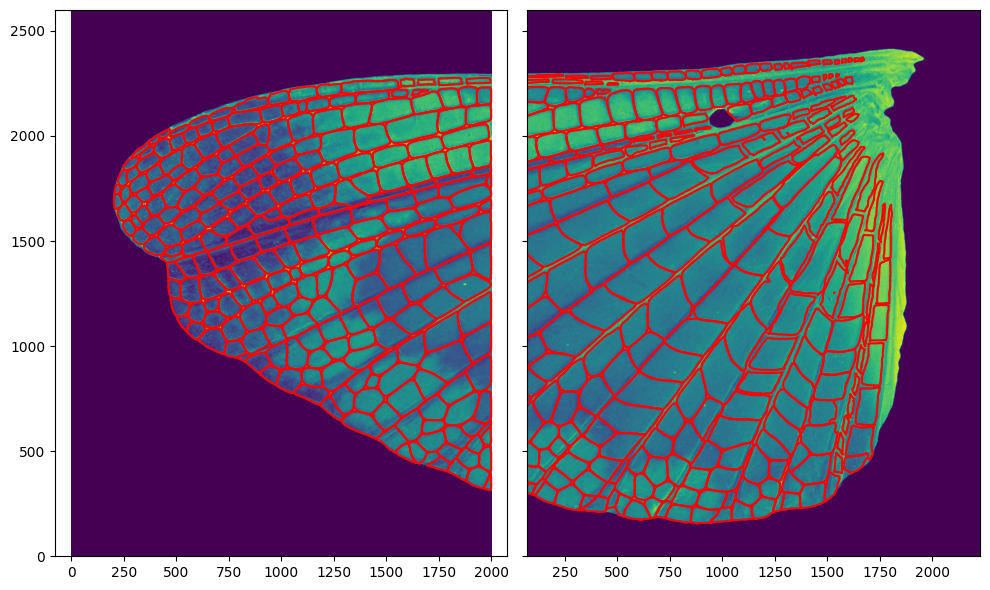

In [74]:

dat1 = np.load('crop_hind_1_pos_part1_seg.npy', allow_pickle=True).item()
dat2 = np.load('crop_hind_1_pos_part2_seg.npy', allow_pickle=True).item()


# plot image with masks overlaid
mask_RGB1 = plot.mask_overlay(dat1['img'], dat1['masks'],colors=np.array(dat1['colors']))
mask_RGB2= plot.mask_overlay(dat2['img'], dat2['masks'],colors=np.array(dat2['colors']))

# plot image with outlines overlaid in red
outlines1= utils.outlines_list(dat1['masks'])
outlines2 = utils.outlines_list(dat2['masks'])


fig,ax=plt.subplots(1,2,sharey=True,figsize=(10,6))
ax[0].imshow(dat1['img'])
ax[0].set_ylim(0,2600)
ax[1].imshow(dat2['img'])
ax[1].set_ylim(0,2600)

for o in outlines1:
    ax[0].plot(o[:,0], o[:,1], color='r')

for o in outlines2:
    ax[1].plot(o[:,0], o[:,1], color='r')

ax[0].axis('equal')  
ax[1].axis('equal')
fig.tight_layout()
plt.savefig("cp_outline.png",dpi=1000)


In [29]:
tmp=np.copy(dat1['masks'])
tmp[np.nonzero(tmp)]=1

In [15]:
tmp.shape

(2600, 2000)

In [27]:
dat1['img'].shape

(2600, 2000)

In [25]:
outlines1[10][:,1]

array([493, 494, 494, 495, 495, 496, 496, 496, 497, 497, 498, 498, 499,
       499, 500, 501, 501, 502, 502, 503, 504, 504, 505, 505, 506, 507,
       507, 508, 509, 509, 510, 511, 511, 512, 513, 514, 515, 516, 517,
       517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529,
       530, 531, 532, 533, 534, 535, 536, 536, 537, 538, 539, 540, 541,
       541, 542, 543, 543, 544, 545, 545, 546, 547, 547, 548, 548, 549,
       550, 550, 551, 551, 551, 552, 553, 553, 554, 554, 555, 556, 557,
       557, 558, 559, 559, 560, 561, 562, 563, 563, 564, 565, 566, 567,
       568, 568, 569, 570, 571, 572, 573, 573, 574, 575, 576, 577, 578,
       578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 588, 588,
       589, 589, 590, 590, 591, 591, 592, 593, 593, 594, 594, 595, 596,
       596, 597, 597, 598, 599, 599, 600, 601, 602, 603, 604, 605, 605,
       606, 607, 607, 608, 608, 609, 610, 610, 611, 611, 612, 613, 613,
       614, 615, 616, 616, 617, 618, 618, 619, 619, 620, 621, 62

In [59]:
dat1['img'][0,0]

0.0

In [69]:
np.max(result)

1.0

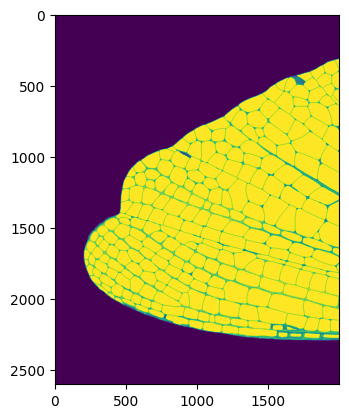

In [73]:
# plt.imshow(tmp)
result=np.copy(dat1['img'])/255.
tmp=np.copy(dat1['masks'])
result[np.nonzero(tmp)]=1
result=result.astype('float64')
# tmp2=tmp.T
for o in outlines1:
    # print(np.max(o[:,1]))
    # if np.max(o[:,1])<2000:
    result[o[:,1], o[:,0]]=0.5 
    # print(result[o[:,1], o[:,0]])

# plt.imshow(dat1['img'])
plt.imshow(result)
plt.imsave("outline2.png",result)
np.save('outline.txt',result)


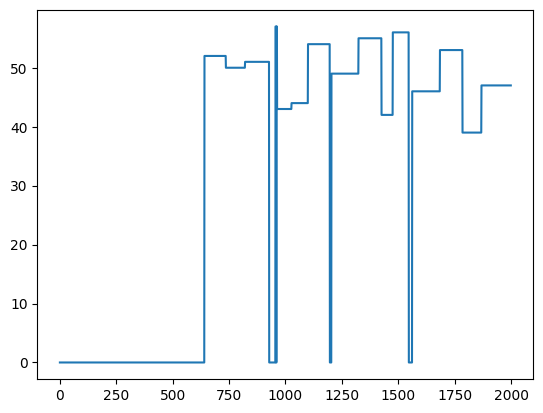

In [66]:
plt.plot(tmp[1000,:])

In [151]:
dat1['masks'].shape

(2600, 2000)

In [139]:
np.max(tmp)

1

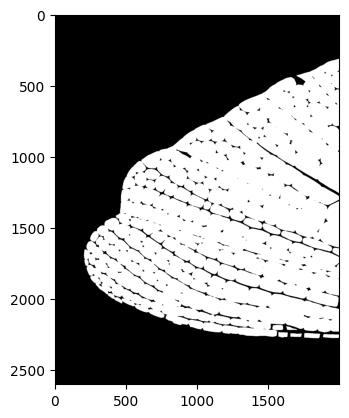

In [145]:
plt.imshow(tmp,cmap=plt.cm.gray)
plt.imsave("outline.png",tmp,cmap=plt.cm.gray)

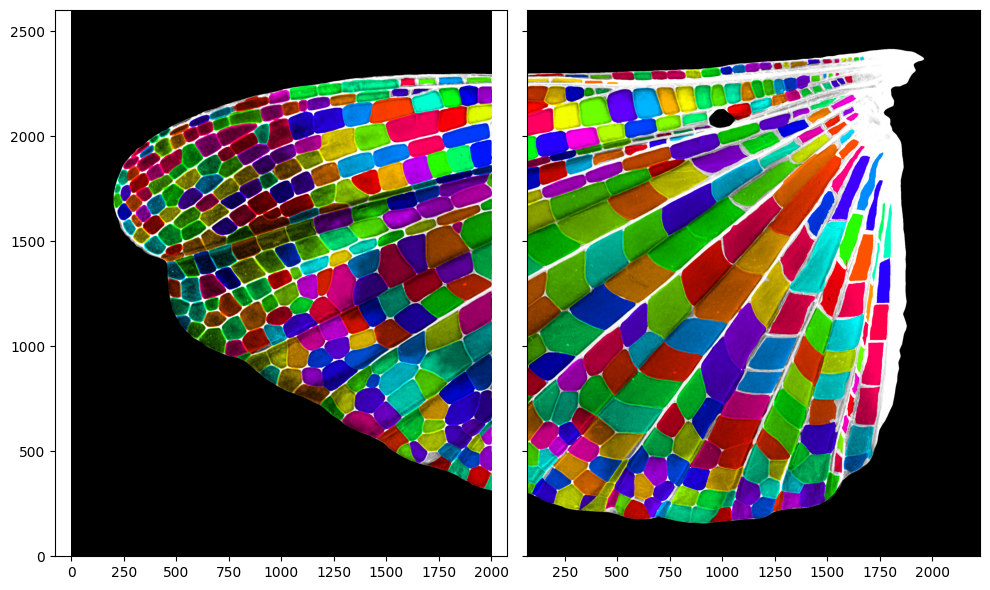

In [75]:
# plot masks
fig,ax=plt.subplots(1,2,sharey=True,figsize=(10,6))
ax[0].imshow(mask_RGB1)
ax[1].imshow(mask_RGB2)
ax[0].axis('equal')  
ax[1].axis('equal')
ax[0].set_ylim(0,2600)
ax[1].set_ylim(0,2600)
fig.tight_layout()
plt.savefig("cp_mask.png",dpi=1000)

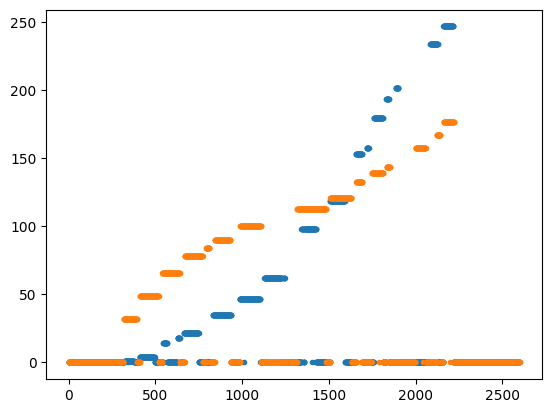

In [38]:
plt.plot(dat1['masks'][:,-1],'.')
plt.plot(dat2['masks'][:,0],'.')


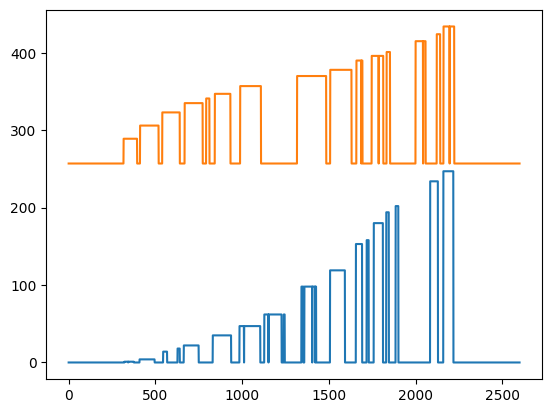

In [53]:
plt.plot(mask1[:,-1])
plt.plot(mask2[:,0])

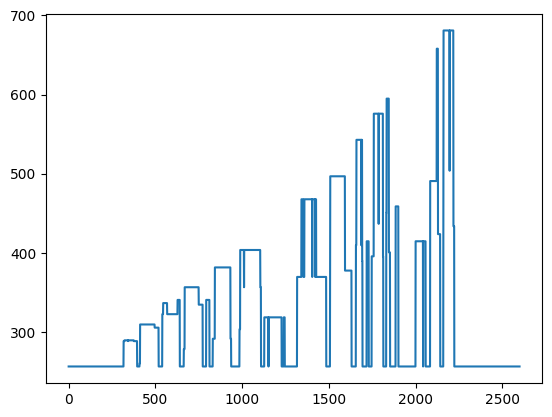

In [56]:
plt.plot(mask2[:,0]+mask1[:,-1])

In [108]:
mask2=copy.deepcopy(dat2['masks'])
# mask1=dat1['masks']+np.max(dat2['masks'])
mask1=copy.deepcopy(dat1['masks'])

In [123]:
# merge masks 
(N1,M1)=np.shape(mask1)
(N2,M2)=np.shape(mask2)
if N1!=N2: 
    print("the vertical axis does not agree")
else:
    N=N1
    M=M1+M2
    
merge_mask=np.hstack((mask1,mask2))

# use nonzero segments in mask1 to match mask2
# a=mask1[:,-1]-np.max(dat2['masks'])
a=mask1[:,-1]
aa=np.nonzero(a)[0]
seg_a=aa[1:]-aa[0:-1]-1
seg_aa=np.nonzero(seg_a)[0]

b=mask2[:,0]
bb=np.nonzero(b)[0]
seg_b=bb[1:]-bb[0:-1]-1
seg_bb=np.nonzero(seg_b)[0]

idxb=0
for i in range(len(seg_bb)):
    lb=bb[idxb:seg_bb[i]+1]
    idxb=seg_bb[i]+1
    idxa=0
    for j in range(len(seg_aa)):
        la=aa[idxa:seg_aa[j]+1]
        idxa=seg_aa[j]+1
        # print("la:",la)
        # print("lb:",lb)
        
        if np.sum(np.isin(lb,la))>3:
            print("merge:",la,lb)
            # merge_mask[merge_mask==b[lb[0]]]=a[la[0]]+np.max(dat2['masks'])
            merge_mask[merge_mask==b[lb[0]]]=a[la[0]]
            merge_mask[la,M1-1]=a[la[0]]
            merge_mask[la,M1]=a[la[0]]
            merge_mask[lb,M1-1]=a[la[0]]
            merge_mask[lb,M1]=a[la[0]]
        
    

merge: [322 323 324 325 326 327 328 329 330 331 332 333 334 335 336 337 338 339
 340 341 342] [317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333 334
 335 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351 352
 353 354 355 356 357 358 359 360 361 362 363 364 365 366 367 368 369 370
 371 372 373 374 375 376 377 378 379 380 381 382 383 384 385 386 387 388
 389 390 391 392 393 394]
merge: [344 345 346 347 348 349 350 351 352 353 354 355 356 357 358 359 360 361
 362 363 364 365 366 367 368 369 370 371 372 373 374 375] [317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333 334
 335 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351 352
 353 354 355 356 357 358 359 360 361 362 363 364 365 366 367 368 369 370
 371 372 373 374 375 376 377 378 379 380 381 382 383 384 385 386 387 388
 389 390 391 392 393 394]
merge: [409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 424 425 426
 427 428 429 430 431 432 433 434 435 436 437 438 439

In [124]:
# dat1 = np.load('crop_hind_1_pos_part1_seg.npy', allow_pickle=True).item()
# dat2 = np.load('crop_hind_1_pos_part2_seg.npy', allow_pickle=True).item()

merge_img=np.hstack((dat1['img'],dat2['img']))
merge_mask_RGB= plot.mask_overlay(merge_img, merge_mask)

In [117]:
M1

2000

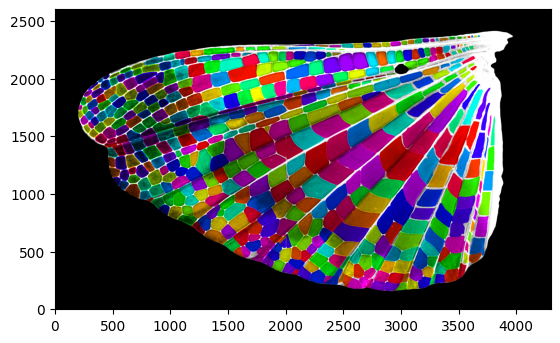

In [125]:
plt.imshow(merge_mask_RGB)
plt.ylim(0,2600)
plt.savefig("cp_merge_mask.png",dpi=600)

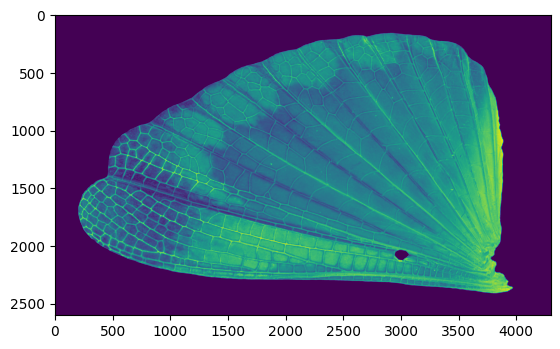

In [84]:
plt.imshow(merge_img)

In [97]:
a=mask1[:,-1]
aa=np.nonzero(a)[0]
seg_a=aa[1:]-aa[0:-1]-1

b=dat2['masks'][:,0]
bb=np.nonzero(b)[0]
seg_b=bb[1:]-bb[0:-1]-1

In [99]:
np.nonzero(seg_b)[0]



array([  77,  184,  285,  389,  408,  498,  618,  786,  909,  937,  943,
        983, 1009, 1029, 1072, 1086, 1106, 1141])

In [108]:
bb[0:78],bb[78:185]

(array([317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329,
        330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342,
        343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355,
        356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368,
        369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381,
        382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394]),
 array([412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424,
        425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437,
        438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450,
        451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463,
        464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476,
        477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489,
        490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502,
        503, 504, 505, 506, 507, 508, 509, 510, 5

In [87]:
aa[1:]-aa[0:-1]

array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   2,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
        34,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,  50,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,  61,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,  24,   1,   1,   1,   1,   

In [75]:
b=mask2[:,0]-257
np.nonzero(b)[0].shape

(1168,)

In [74]:
b=

array([257, 257, 257, ..., 257, 257, 257], dtype=uint16)

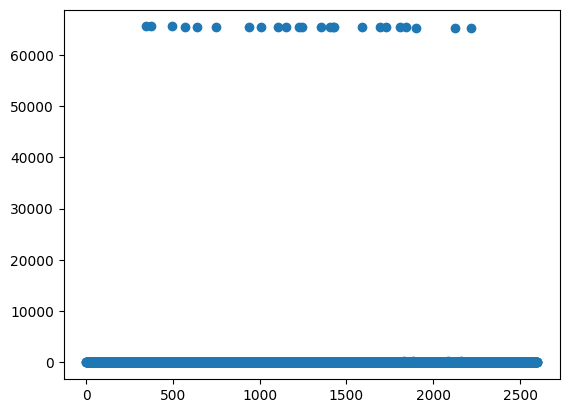

In [78]:
plt.plot(a[1:]-a[0:-1],'o')